## Creating a Linear Regression Model

### Discovery

You have been tasked with trying to determine if there is a linear relationship between the cost of oil and the S&P 500 valuation. You will use a linear regression model to establish if any relationship exists and if so, how oil prices are impacted by stock market fluctuations.

First we will import the required modules. They are:
- pandas
- seaborn
- statsmodels.api
- sklearn.model_selection - train_test_split

In [9]:
# Import required modules/libraries
import pandas as pd # Used to clean and manipulate data
import matplotlib.pyplot as plt # Another viz library
import seaborn as sns # Visualisations
import statsmodels.api as sm # One of the ML libraries
from sklearn.model_selection import train_test_split # Another ML library
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error # Compute statistics

--- 
### Data preparation
We import the dataset, telling pandas to set the index column as the date, ensuring it is a datetime format and cofnirming the input format. We then validate the results. 

In [ ]:
# Import the first dataset and set the date as the index
carbon_df = pd.read_csv("df_fuel_ckan.csv", index_col="DATETIME", parse_dates=True)
carbon_df.tail(10)
#test

,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
DATETIME,,,,,,,,,,,,,,,,,,,,,
2026-05-28 02:30:00,4402.0,0.0,2267.0,9583.0,1791.0,88.0,3738.0,2399.0,383.0,0.0,...,15.2,9.7,1.6,0.0,0.0,100.0,65.4,75.0,46.5,17.9
2026-05-28 03:00:00,4411.0,0.0,2269.0,9306.0,1799.0,115.0,3332.0,2394.0,445.0,0.0,...,13.8,9.9,1.8,0.0,0.0,100.0,66.0,74.4,46.6,18.3
2026-05-28 03:30:00,4300.0,0.0,2266.0,8970.0,1813.0,115.0,3320.0,2400.0,424.0,0.0,...,14.1,10.2,1.8,0.0,0.0,100.0,65.9,74.4,46.2,18.2
2026-05-28 04:00:00,4597.0,0.0,2268.0,8658.0,1817.0,114.0,2794.0,2402.0,476.0,68.0,...,12.0,10.4,2.1,0.3,0.0,100.0,66.1,72.6,45.9,19.8
2026-05-28 04:30:00,5403.0,0.0,2269.0,8375.0,1798.0,90.0,2802.0,2402.0,269.0,471.0,...,11.7,10.1,1.1,2.0,0.0,100.0,64.5,69.8,45.0,22.6
2026-05-28 05:00:00,5799.0,0.0,2266.0,8156.0,1755.0,121.0,3984.0,2393.0,450.0,1017.0,...,15.4,9.2,1.7,3.9,0.0,100.0,60.6,67.4,42.6,22.4
2026-05-28 05:30:00,5848.0,0.0,2263.0,7848.0,1702.0,131.0,4126.0,2378.0,1209.0,1728.0,...,15.2,8.7,4.4,6.3,0.0,100.0,58.9,64.1,41.9,21.5
2026-05-28 06:00:00,4593.0,0.0,2265.0,7875.0,1641.0,169.0,5246.0,2387.0,526.0,2672.0,...,19.2,8.7,1.9,9.8,0.0,100.0,62.1,71.3,45.1,16.8
2026-05-28 06:30:00,3487.0,0.0,2264.0,8443.0,1575.0,179.0,5374.0,2302.0,1257.0,3684.0,...,18.7,8.0,4.4,12.9,0.4,100.0,64.7,73.7,48.8,12.2


In [12]:
# Removed unrequired data and renamed close price
carbon_df = carbon_df[["GAS","COAL","WIND","SOLAR","CARBON_INTENSITY"]]
carbon_df.tail(10)

,GAS,COAL,WIND,SOLAR,CARBON_INTENSITY
DATETIME,,,,,
2026-05-28 02:30:00,4402.0,0.0,9583.0,0.0,92.0
2026-05-28 03:00:00,4411.0,0.0,9306.0,0.0,95.0
2026-05-28 03:30:00,4300.0,0.0,8970.0,0.0,94.0
2026-05-28 04:00:00,4597.0,0.0,8658.0,68.0,101.0
2026-05-28 04:30:00,5403.0,0.0,8375.0,471.0,109.0
2026-05-28 05:00:00,5799.0,0.0,8156.0,1017.0,109.0
2026-05-28 05:30:00,5848.0,0.0,7848.0,1728.0,113.0
2026-05-28 06:00:00,4593.0,0.0,7875.0,2672.0,94.0
2026-05-28 06:30:00,3487.0,0.0,8443.0,3684.0,82.0


--- 
### Model planning
You will now need to understand which variables have a relationship from the prepared data. Identifying the strength and direction of the relationships will help to build a useful model, within the remit of the task. 

We first create a correlation matrix to establish the relationships between variables. We will only use 1 indepednent and 1 depedant variable for this model. 

<Axes: >

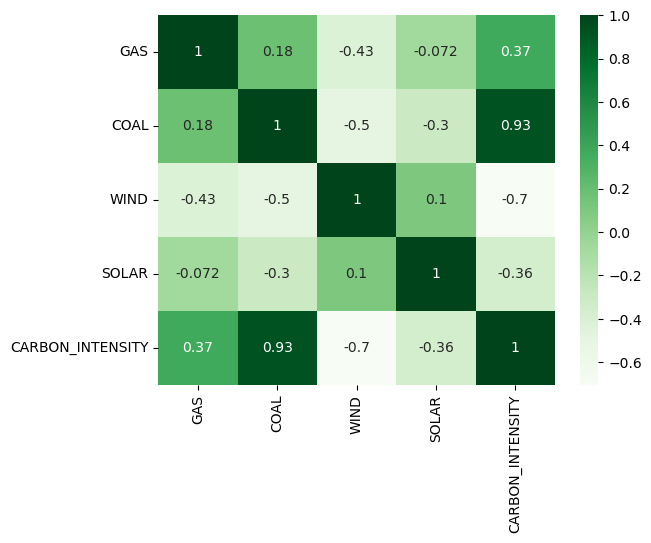

In [13]:
# Use price as dependent and select another appropriate variable to predict the output. 
carbon_corr = carbon_df.corr()
sns.heatmap(carbon_corr, annot=True, cmap="Greens")

Create a Regplot/Scatterplot to demonstrate the relationship between our dependent and independent variable. 

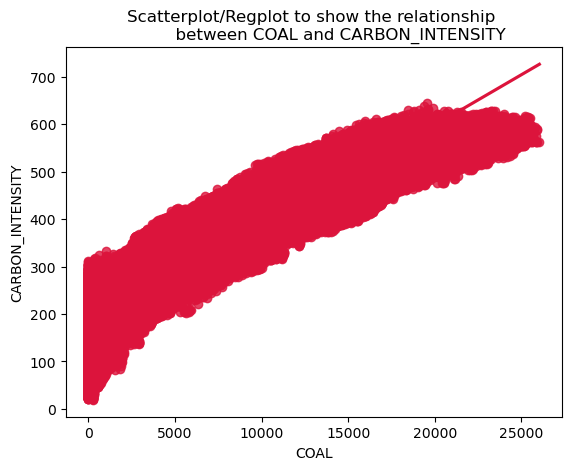

In [16]:
# Check the relationship between the selected variables
sns.regplot(x = "COAL",
            y = "CARBON_INTENSITY",
            color="Crimson",
            data = carbon_df
)

# Add title with multiline string and new line
plt.title("""Scatterplot/Regplot to show the relationship 
          between COAL and CARBON_INTENSITY""")

# Display visual with title
plt.show()

---
### Building the model
Before building the model we split the data into training and test datasets. The model will be build using the train data and tested using the test data. We include the random_state argument to make the results replicable: <br>

In [17]:
# Split the data into train and test samples
train, test = train_test_split(carbon_df,random_state=25)

We then set the independent variable and dependent variables. <br>
Y/Dependent/Output - the variable we are predicting <br>
X/Independent/Input Variable(s) - the variable(s) we are testing the impact of.

In [21]:
# Set the dependent variable and validate
dep = train["CARBON_INTENSITY"]
dep.head()

DATETIME
2012-01-31 13:00:00    569.0
2015-03-16 11:00:00    479.0
2021-02-07 13:00:00    128.0
2009-05-15 23:00:00    425.0
2023-06-05 11:30:00    144.0
Name: CARBON_INTENSITY, dtype: float64

Add the constant to the independent variable where we do not wish the intercept/c to run through zero. This makes sense in this example as Oil would still hold value in other currencies, should the S&P 500 crash. 

In [22]:
# Set the independent variable and validate
ind = train[["GAS","COAL","WIND","SOLAR"]]
ind = sm.add_constant(ind)
ind.head()

,const,GAS,COAL,WIND,SOLAR
DATETIME,,,,,
2012-01-31 13:00:00,1.0,14290.0,24527.0,1113.0,0.0
2015-03-16 11:00:00,1.0,16469.0,16075.0,697.0,869.0
2021-02-07 13:00:00,1.0,11185.0,316.0,12858.0,1583.0
2009-05-15 23:00:00,1.0,13455.0,7850.0,680.0,0.0
2023-06-05 11:30:00,1.0,10858.0,0.0,1387.0,8100.0


Now generate the model along with a summary output. 

In [23]:
# Fit the model and produce the summary
model = sm.OLS(dep,ind).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       CARBON_INTENSITY   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                 1.238e+06
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:06:32   Log-Likelihood:            -1.1135e+06
No. Observations:              228827   AIC:                         2.227e+06
Df Residuals:                  228822   BIC:                         2.227e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        215.0241      0.248    868.484      0.000     214.539     215.509
GAS            0.0029   1.31e-05    220.061      0.000       0.003       0.003
COAL           0.0169   1.22e-05   1386.328      0.000       0.017       0.017
WIND          -0.0110   2.12e-05   -517.477      0.000      -0.011      -0.011
SOLAR         -0.0078    3.5e-05   -221.879      0.000      -0.008      -0.008
==============================================================================
Omnibus:                     6594.262   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10981.956
Skew:                          -0.265   Prob(JB):                         0.00
Kurtosis:                       3.934   Cond. No.                     5.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

--- 
### Communicating the results. 
We will now analyse the model and communicate the results, paying particular focus on the following ouptuts.

- R-Squared (R²) : R-squared measures the proportion of the variance in the dependent variable that is explained by the independent variables. It ranges from 0 to 1, where 1 indicates that the model explains all the variance.

- F-Statistic: The F-statistic is used to test the overall significance of the model. The null hypothesis is that all coefficients (except the intercept) are zero, meaning the model does not explain any variance in the dependent variable. This value should be greater than 1 but the higher the number, the better.  

- Prob (F-Statistic): - The p-value associated with the F-statistic indicates the probability of observing the F-statistic (or a more extreme value) if the null hypothesis were true. A small p-value (typically less than 0.05) indicates that the model is statistically significant, meaning at least one of the independent variables has a significant effect on the dependent variable.


- P-Value: The p-value indicates the probability of observing the estimated coefficient if the null hypothesis were true. A p-value below a certain significance level (usually 0.05) suggests that the coefficient is statistically significant, meaning the independent variable has a significant effect on the dependent variable.

- Coefficient: The coefficient term tells the change in Y for a unit change in X. In our model a 1 unit change in S&P Close Price will lead to a 1.3205 decrease in Oil Cost.

- Constant: The constant terms is the intercept of the regression line. This represents the baseline of a the output variable, assuming input variables are set to 0.

Now lets test the model output - remember to add a constant to your test data. 

In [24]:
# Set the test sample independent variable and use the model to predict the variable, using the test dataset 
test_ind = test[["GAS","COAL","WIND","SOLAR"]]
test_ind = sm.add_constant(test_ind)
output = model.predict(test_ind)

Finally, add a predicted column to your test dataset, where you have your prediction shown, alongside your actual values for your dependent variable. 

In [27]:
# Add the predicted values to our test dataframe to compare actual with predicted. 
test["PREDICTED_CARBON_INTENSITY"] = output
test.head()
#test = pd.to_csv("outputdata")

,GAS,COAL,WIND,SOLAR,CARBON_INTENSITY,predicted,PREDICTED_CARBON_INTENSITY
DATETIME,,,,,,,
2017-12-03 04:30:00,8193.0,3497.0,3874.0,0.0,272.0,255.116939,255.116939
2014-02-11 01:00:00,4421.0,15890.0,2778.0,0.0,503.0,465.123745,465.123745
2017-07-27 07:00:00,12295.0,583.0,3412.0,1275.0,199.0,212.998684,212.998684
2010-05-08 13:30:00,18557.0,9256.0,288.0,0.0,451.0,421.432264,421.432264
2017-08-27 06:00:00,6967.0,885.0,482.0,344.0,219.0,242.088563,242.088563


With the predicted values, to compare against what actual values, we can calculate some additional statistics to validate the quality of our model.
- RMSE - the square root of the average of squared prediction errors, which shows how far predictions are from actual values with bigger mistakes weighted more heavily.
- MAPE - the average percentage difference between predicted and actual values, which shows prediction error in percent terms.
- MAE - the average of the absolute prediction errors, which shows the typical size of mistakes without caring whether they are above or below the actual values.
- MSE - the average of squared prediction errors, which shows overall error while giving extra weight to larger mistakes.

In [28]:
# Root mean squared error - 
rmse = root_mean_squared_error(test["CARBON_INTENSITY"],test["PREDICTED_CARBON_INTENSITY"])
print(rmse)

31.41268880558364


In [29]:
from sklearn import metrics
metrics.mean_absolute_error(test["CARBON_INTENSITY"],test["PREDICTED_CARBON_INTENSITY"])

23.70887499739033

In [30]:
mape = mean_absolute_percentage_error(test["CARBON_INTENSITY"],test["PREDICTED_CARBON_INTENSITY"])
print(mape)

0.12182435581295623


In [31]:
mae = mean_absolute_error(test["CARBON_INTENSITY"],test["PREDICTED_CARBON_INTENSITY"])
print(mae)

23.70887499739033


In [32]:
mse = mean_squared_error(test["CARBON_INTENSITY"],test["PREDICTED_CARBON_INTENSITY"])
print(mse)

986.7570179964398


We can go further than this if we wanted to, and measure the actual values against the predicted to see how well they align. Additionally, we might like to plot residuals to see the dispersion of outliers. Outliers close to zero are preferred, with a normal distribution. 

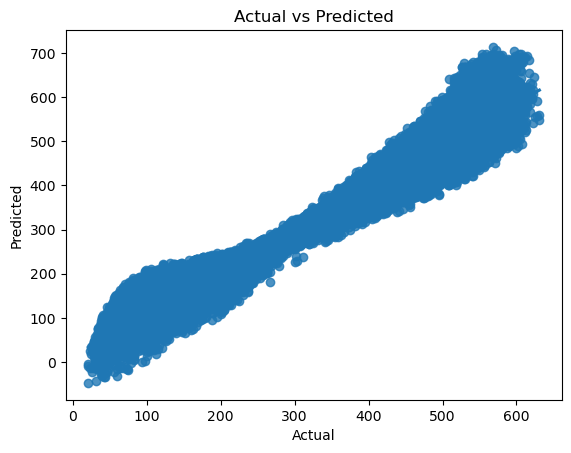

In [33]:
# Plot the actual, compared with predicted. 
# Should be on a 45° incline to show good predictions.
sns.regplot(x="CARBON_INTENSITY", y="PREDICTED_CARBON_INTENSITY", data = test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

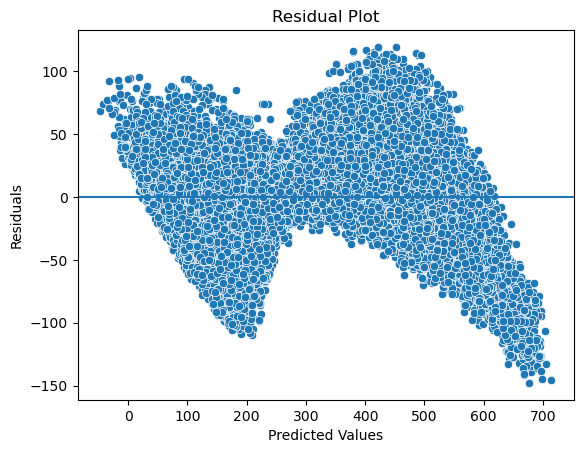

In [34]:
# Plot redsiduals to understand dispersion of outliers.
# Should be centered around 0

residuals = test["CARBON_INTENSITY"] - test["PREDICTED_CARBON_INTENSITY"]
sns.scatterplot(x=test["predicted"], y=residuals, data = test)

plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



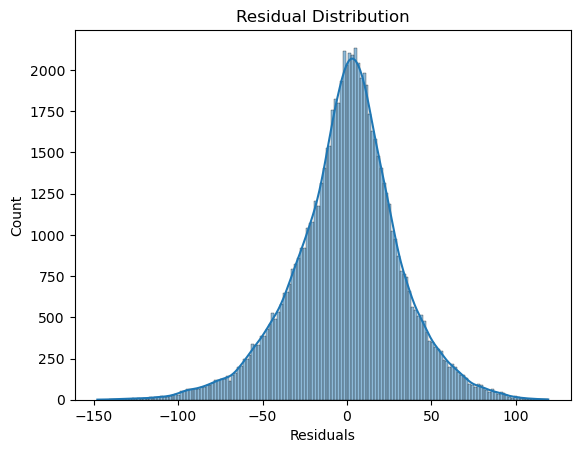

In [35]:
# Plot the distribution of residuals 
# Should look like a bell-curve when correct
sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Residual Distribution")

plt.show()

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process. In this case, I am simply going to create a small sample dataset, and run this through the model to compare what the model predicted would happen, against what actually did. 